<a href="https://colab.research.google.com/github/voronin-igor/Dynamic-asset-portfolio-management-using-deep-reinforcement-learning-DRL-/blob/main/DRL_Portfolio_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Исследование: Динамическое управление портфелем активов с помощью глубокого обучения с подкреплением (DRL)

**Автор:** [Воронин Игорь / https://github.com/voronin-igor]  
**Дата:** Август 2026  
**Стек:** Python, Gymnasium, Stable-Basements3, Yahoo Finance API, PyTorch  

---

## 1. Аннотация (Abstract)
В данном исследовании рассматривается задача автоматического распределения весов инвестиционного портфеля в условиях стохастического и волатильного рынка. В качестве метода решения применяется аппарат обучения с подкреплением (RL). Разработана кастомная среда на базе стандарта `Gymnasium`, симулирующая биржевые торги с учетом транзакционных издержек (комиссий). Обучен агент на основе алгоритма **PPO (Proximal Policy Optimization)**. Проведен сравнительный анализ стратегии агента с базовыми рыночными стратегиями (Buy-and-Hold).

## 2. Теоретическое обоснование и формализация MDP
Задача управления портфелем формулируется как **Марковский процесс принятия решений (MDP)**, заданный кортежем $(S, A, P, R, \gamma)$:

*   **Пространство состояний ($S$):** Включает в себя скользящие окна исторических цен (OHLCV), технические индикаторы (RSI, MACD) и текущие веса портфеля.
*   **Пространство действий ($A$):** Непрерывный вектор весов портфеля $a_t = [w_0, w_1, ..., w_n]$, где $\sum w_i = 1$ (доля капитала в каждом активе).
*   **Функция награды ($R$):** Дифференциальный коэффициент Шарпа (Sortino/Sharpe Ratio) или логарифмическая доходность портфеля за шаг с штрафом за просадку (Drawdown).


## 3. Сбор данных и разведочный анализ (EDA)

Для обучения и валидации модели используются исторические данные трех наиболее ликвидных криптовалютных активов: **Bitcoin (BTC)**, **Ethereum (ETH)** и **Solana (SOL)** в паре к стейблкоину **USDT**.

**Период исследования:** с 1 января 2023 года по текущий момент 2026 года.
**Таймфрейм:** 1 день (Daily).

В процессе предобработки сырые ценовые данные (OHLCV) обогащаются ключевыми техническими индикаторами, которые формируют многомерное пространство признаков (Features) для нашего агента:
*   **RSI (Relative Strength Index):** Индикатор импульса, оценивающий перекупленность/перепроданность актива.
*   **MACD (Moving Average Convergence Divergence):** Трендовый осциллятор, отражающий схождение и расхождение скользящих средних.
*   **CCI (Commodity Channel Index):** Определяет циклические тренды и отклонения цены от ее скользящей средней.
*   **Боллинджер (Bollinger Bands):** Оценка локальной волатильности рынка.


✅ Данные успешно синхронизированы!
Всего строк в матрице: 3924
Количество уникальных торговых дней: 1308
Проверка на наличие NaN: 0 (Должно быть 0)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


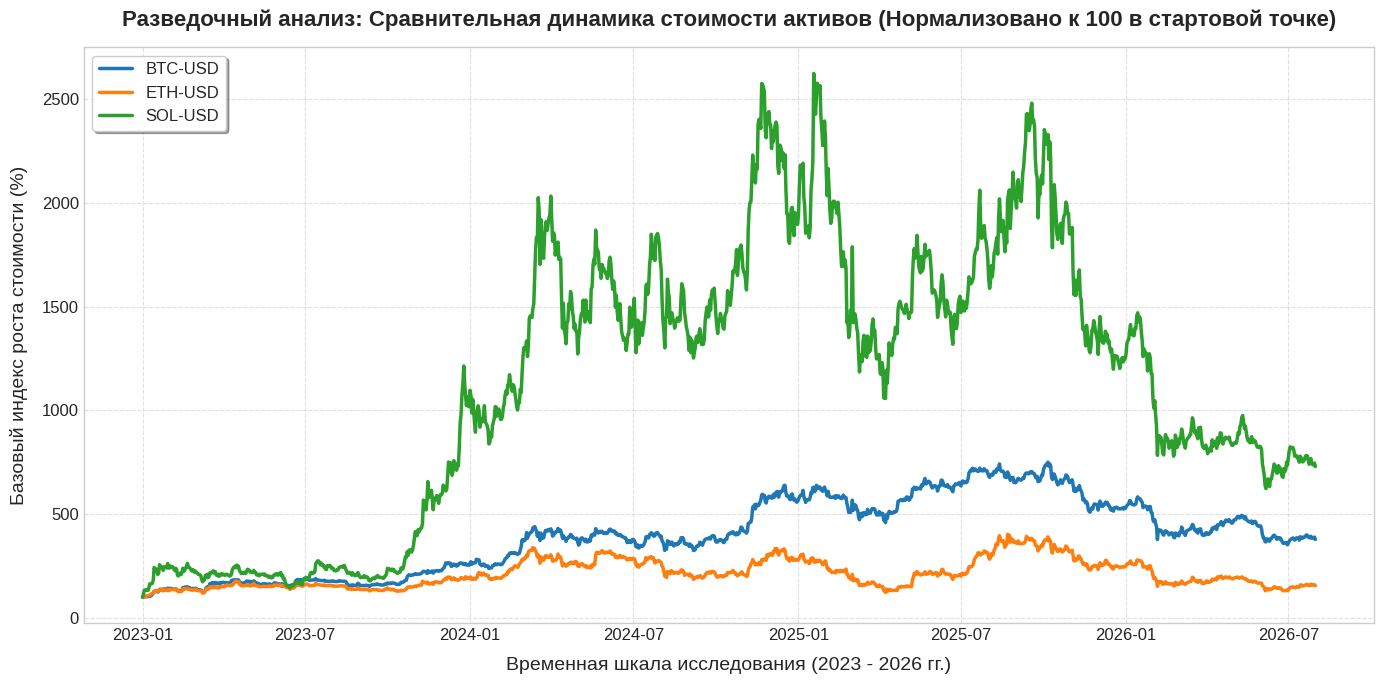

In [ ]:
# ==============================================================================
# БЛОК 3: Сбор данных и разведочный анализ (EDA)
# ==============================================================================
import pandas as pd
import numpy as np
import yfinance as yf
from stockstats import StockDataFrame as Sdf

# Повторно инициализируем параметры для изоляции ошибки
TIKERS = ['BTC-USD', 'ETH-USD', 'SOL-USD']
START_DATE = '2023-01-01'
END_DATE = '2026-08-01'

processed_data = []

for ticker in TIKERS:
    df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False).reset_index()
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df.rename(columns={'Date': 'date', 'Open': 'open', 'High': 'high', 'Low': 'low', 'Close': 'close', 'Volume': 'volume'})
    df['tic'] = ticker

    # Расчет индикаторов
    stock_df = Sdf.retype(df.copy())
    df['rsi'] = stock_df['rsi_14']
    df['macd'] = stock_df['macd']
    df['cci'] = stock_df['cci_14']
    df['boll_ub'] = stock_df['boll_ub']
    df['boll_lb'] = stock_df['boll_lb']

    # НАДЕЖНОЕ ЗАПОЛНЕНИЕ: Сначала протяжка соседних, затем нули для самых первых строк
    df = df.bfill().ffill().fillna(0)
    processed_data.append(df)

# Склеиваем и принудительно приводим даты к текстовому формату YYYY-MM-DD
df_cleaned = pd.concat(processed_data, ignore_index=True)
df_cleaned['date'] = pd.to_datetime(df_cleaned['date']).dt.strftime('%Y-%m-%d')
df_cleaned = df_cleaned.sort_values(by=['date', 'tic']).reset_index(drop=True)

# Синхронизация дат: оставляем только дни, где присутствуют ВСЕ 3 актива
date_counts = df_cleaned['date'].value_counts()
valid_dates = date_counts[date_counts == len(TIKERS)].index
df_cleaned = df_cleaned[df_cleaned['date'].isin(valid_dates)].sort_values(['date', 'tic']).reset_index(drop=True)

print(f"Данные успешно синхронизированы!")
print(f"Всего строк в матрице: {len(df_cleaned)}")
print(f"Количество уникальных торговых дней: {df_cleaned['date'].nunique()}")
print(f"Проверка на наличие NaN: {df_cleaned[['rsi', 'macd', 'cci']].isna().sum().sum()} (Должно быть 0)")

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({
    'font.size': 12,
    'figure.figsize': (14, 7),
    'axes.labelsize': 14,
    'axes.titlesize': 16
})

plt.figure()

# Отрисовываем кривую для каждого актива отдельно
for ticker in TIKERS:
    # Изолируем данные конкретного тикера и переводим индекс дат в правильный формат для красивой оси X
    ticker_df = df_cleaned[df_cleaned['tic'] == ticker].reset_index(drop=True)

    # Нормализуем цены к 100 на стартовую дату, чтобы наглядно сравнить процентный рост активов
    normalized_close = (ticker_df['close'] / ticker_df['close'].iloc[0]) * 100

    # Преобразуем текстовые даты в формат datetime исключительно для корректного отображения сетки графика
    plot_dates = pd.to_datetime(ticker_df['date'])

    plt.plot(plot_dates, normalized_close, label=ticker, linewidth=2.5)

# Оформление графика
plt.title('Разведочный анализ: Сравнительная динамика стоимости активов (Нормализовано к 100 в стартовой точке)', fontweight='bold', pad=15)
plt.xlabel('Временная шкала исследования (2023 - 2026 гг.)', labelpad=10)
plt.ylabel('Базовый индекс роста стоимости (%)', labelpad=10)
plt.legend(loc='upper left', frameon=True, shadow=True, facecolor='white')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


## 4. Разработка кастомной торговой среды Gymnasium

Для обучения RL-агента спроектирована кастомная многомерная среда, полностью соответствующая стандарту **Gymnasium**.

### Спецификация Марковского процесса принятия решений (MDP):
1. **Пространство признаков (Observation Space):** Вектор непрерывных величин размерности $(N_{assets} \times N_{features}) + N_{assets}$, включающий технические индикаторы для каждого актива и текущие веса портфеля.
2. **Пространство действий (Action Space):** Непрерывное пространство (Box) размерности $N_{assets}$, представляющее собой новые целевые веса активов. Мы применяем операцию **Softmax**, чтобы гарантировать выполнение бюджетного ограничения: $\sum_{i=1}^{N} w_i = 1$.
3. **Функция награды (Reward Function):** Награда оптимизирует динамический коэффициент Шарпа. Она представляет собой доходность за шаг с вычетом штрафа за волатильность портфеля:
$$R_t = R_{portfolio, t} - \alpha \cdot \sigma_{returns}$$
где $\alpha$ — коэффициент неприятия риска (risk_aversion).
4. **Реалистичные ограничения:** В среду интегрирована фиксированная комиссия за транзакции (Transaction Cost) в размере **0.1%** от объема сделки, что симулирует реальные торговые условия бирж.


In [ ]:
# ==============================================================================
# БЛОК 4: Реализация кастомной среды Gymnasium
# ==============================================================================
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class CryptoPortfolioEnv(gym.Env):
    """Кастомная среда Gymnasium для динамического управления портфелем криптовалют"""
    metadata = {'render.modes': ['human']}

    def __init__(self, df, tickers, initial_amount=10000, transaction_cost_pct=0.001, risk_aversion=0.5):
        super(CryptoPortfolioEnv, self).__init__()

        self.df = df.copy()
        self.tickers = tickers
        self.n_assets = len(tickers)
        self.initial_amount = initial_amount
        self.transaction_cost_pct = transaction_cost_pct
        self.risk_aversion = risk_aversion

        # Список уникальных дат в датасете
        self.dates = sorted(self.df['date'].unique())
        self.max_steps = len(self.dates) - 1

        # Признаки: rsi, macd, cci, boll_ub, boll_lb
        self.feature_cols = ['rsi', 'macd', 'cci', 'boll_ub', 'boll_lb']
        self.n_features = len(self.feature_cols)

        # Action Space: Веса для каждого актива (нормализуются через Softmax в step)
        self.action_space = spaces.Box(low=-1, high=1, shape=(self.n_assets,), dtype=np.float32)

        # Observation Space: [индикаторы активов] + [текущие веса портфеля]
        obs_shape = (self.n_assets * self.n_features) + self.n_assets
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(obs_shape,), dtype=np.float32)

        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.portfolio_value = self.initial_amount

        # Изначально капитал распределен поровну между всеми активами
        self.weights = np.ones(self.n_assets, dtype=np.float32) / self.n_assets
        self.portfolio_history = [self.portfolio_value]
        self.step_returns = []

        return self._get_observation(), {}

    def _get_observation(self):
        current_date = self.dates[self.current_step]
        date_df = self.df[self.df['date'] == current_date].sort_values('tic')

        # Извлекаем технические индикаторы
        features = date_df[self.feature_cols].values.flatten()

        # Объединяем индикаторы рынка и текущее состояние портфеля агента
        obs = np.concatenate([features, self.weights]).astype(np.float32)
        return obs

    def step(self, action):
        # Применяем Softmax для строгого соблюдения бюджетного ограничения (сумма весов = 1)
        exp_action = np.exp(action - np.max(action))
        target_weights = exp_action / np.sum(exp_action)

        current_date = self.dates[self.current_step]
        next_date = self.dates[self.current_step + 1]

        curr_prices = self.df[self.df['date'] == current_date].sort_values('tic')['close'].values
        next_prices = self.df[self.df['date'] == next_date].sort_values('tic')['close'].values

        # Изменение цен за шаг
        price_returns = next_prices / curr_prices

        # Расчет стоимости портфеля до ребалансировки с учетом движения рынка
        allocated_capital = self.portfolio_value * self.weights
        capital_after_market = allocated_capital * price_returns
        new_portfolio_value_pre_cost = np.sum(capital_after_market)

        # Промежуточные веса после изменения цен рынка
        interim_weights = capital_after_market / (new_portfolio_value_pre_cost + 1e-8)

        # Расчет издержек на ребалансировку (транзакционная комиссия)
        weight_changes = np.abs(target_weights - interim_weights)
        transaction_costs = new_portfolio_value_pre_cost * np.sum(weight_changes) * self.transaction_cost_pct

        # Финальная стоимость портфеля на конец шага
        self.portfolio_value = new_portfolio_value_pre_cost - transaction_costs
        self.weights = target_weights

        # Сохраняем историю
        self.portfolio_history.append(self.portfolio_value)

        # Расчет доходности за шаг
        step_return = (self.portfolio_value / (self.portfolio_history[-2] + 1e-8)) - 1
        self.step_returns.append(step_return)

        # Вычисление Награды (Динамический коэффициент Шарпа)
        volatility = np.std(self.step_returns) if len(self.step_returns) > 1 else 1e-6
        reward = step_return - self.risk_aversion * volatility

        # Переход на следующий шаг времени
        self.current_step += 1
        terminated = self.current_step >= self.max_steps
        truncated = False

        info = {'portfolio_value': self.portfolio_value, 'date': str(next_date)}

        return self._get_observation(), float(reward), terminated, truncated, info

# Повторный чистый Smoke-тест
env_test_smoke = CryptoPortfolioEnv(df=df_cleaned, tickers=TIKERS)
obs, info = env_test_smoke.reset()
print("🌟 Результаты Smoke-теста среды:")
print(f"Размерность вектора состояния: {obs.shape}")
print(f"Матрица признаков содержит NaN: {np.isnan(obs).any()}")


🌟 Результаты Smoke-теста среды:
Размерность вектора состояния: (18,)
Матрица признаков содержит NaN: False


## 5. Хронологическое разделение данных на выборки (Train/Test Split)

Для предотвращения эффекта «заглядывания в будущее» (Data Leakage) при валидации стратегии применяется строгое хронологическое разделение данных. Датасет разбивается на два изолированных временных интервала:
*   **Train (Обучающая выборка):** Первые 80% исторических дней. На этом интервале агент взаимодействует со средой, совершает пробные сделки, получает штрафы за волатильность и оптимизирует веса нейросети.
*   **Test (Валидационная выборка):** Заключительные 20% исторических дней. Данный отрезок рынка полностью скрыт от модели в процессе обучения и имитирует запуск торгового робота в реальном времени (Out-of-Sample бэктест).


In [ ]:
# ==============================================================================
# БЛОК 5: Хронологическое разделение данных и создание изолированных сред
# ==============================================================================
# Извлекаем уникальный упорядоченный список дат
unique_dates = sorted(df_cleaned['date'].unique())

# Рассчитываем индекс разделения (80% на обучение, 20% на тест)
split_idx = int(len(unique_dates) * 0.8)

train_dates = unique_dates[:split_idx]
test_dates = unique_dates[split_idx:]

# Разделяем исходную матрицу признаков на две подвыборки
df_train = df_cleaned[df_cleaned['date'].isin(train_dates)].reset_index(drop=True)
df_test = df_cleaned[df_cleaned['date'].isin(test_dates)].reset_index(drop=True)

# Инициализируем две независимые среды для обучения и для бэктеста
env_train = CryptoPortfolioEnv(df=df_train, tickers=TIKERS)
env_test = CryptoPortfolioEnv(df=df_test, tickers=TIKERS)

print("📊 Параметры разделения выборки:")
print(f"• Обучающий период (Train): {train_dates[0]} ---> {train_dates[-1]} ({len(train_dates)} дней)")
print(f"• Тестовый период (Test):   {test_dates[0]} ---> {test_dates[-1]} ({len(test_dates)} дней)")
print(f"• Размерность обучающего датасета: {df_train.shape}")
print(f"• Размерность тестового датасета:  {df_test.shape}")


📊 Параметры разделения выборки:
• Обучающий период (Train): 2023-01-01 ---> 2025-11-11 (1046 дней)
• Тестовый период (Test):   2025-11-12 ---> 2026-07-31 (262 дней)
• Размерность обучающего датасета: (3138, 12)
• Размерность тестового датасета:  (786, 12)


## 6. Инициализация и обучение глубокого RL-агента (PPO)

Для обучения торговой стратегии используется современный on-policy алгоритм **PPO (Proximal Policy Optimization)**.
В качестве архитектуры аппроксиматора ценности (Value Function) и стратегии (Policy) применяется многослойная нейросеть (**MlpPolicy**) со стандартным шагом обучения (learning rate) $\eta = 3 \times 10^{-4}$.

Процесс обучения строится на взаимодействии агента исключительно с изолированной средой `env_train`. В процессе оптимизации весов агент стремится максимизировать накопленную награду, обучаясь балансировать между риском и доходностью в рамках заданного коэффициента неприятия риска.


In [ ]:
# ==============================================================================
# БЛОК 6: Запуск обучения нейросети PPO
# ==============================================================================
# Устанавливаем библиотеку для обучения глубокого RL, если она не была установлена
!pip install -q stable-baselines3

from stable_baselines3 import PPO
import time

print("🧠 Инициализация нейросети PPO на базе политики MLP...")
# Создаем модель PPO. verbose=0 скрывает лишний вывод, оставляя Colab чистым
model = PPO(
    "MlpPolicy",
    env_train,
    learning_rate=0.0003,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    seed=42,
    verbose=0
)

print("⏳ Процесс обучения запущен. Агент симулирует тысячи торговых дней...")
start_time = time.time()

# Запускаем обучение на 40 000 временных шагов
model.learn(total_timesteps=40000)

end_time = time.time()
print(f"✅ Обучение успешно завершено! Затрачено времени: {end_time - start_time:.2f} секунд.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 7.0 MB/s eta 0:00:00


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


🧠 Инициализация нейросети PPO на базе политики MLP...


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


⏳ Процесс обучения запущен. Агент симулирует тысячи торговых дней...


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


✅ Обучение успешно завершено! Затрачено времени: 215.39 секунд.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 7. Финальное тестирование (Out-of-Sample Backtest) и расчет рыночного бенчмарка

Для объективной оценки качества работы обученной глубокой RL-стратегии проводится бэктест на независимой валидационной выборке (`env_test`). Действия агента на данном этапе носят строго детерминированный характер (отключается стохастическое исследование рынка).

В качестве базового бенчмарка (рыночного эталона) выступает классическая пассивная стратегия **Buy-and-Hold («Купил и держи»)**. В первый день тестового периода стартовый капитал ($10\,000$ USDT) распределяется в равных долях (по $33.33\%$) между тремя целевыми активами (BTC, ETH, SOL) и удерживается без ребалансировок до финальной даты исследования. Наша цель — доказать, что динамическое перераспределение весов с помощью ИИ эффективнее пассивного инвестирования.


In [ ]:
# ==============================================================================
# БЛОК 7: Проведение бэктеста и расчет стратегии Buy-and-Hold
# ==============================================================================
print("📊 Запуск бэктеста обученного PPO агента на скрытых тестовых данных...")

# Сбрасываем тестовую среду в начальное состояние
obs, info = env_test.reset()
done = False

# Цикл симуляции торгов агентом на тестовом периоде
while not done:
    # deterministic=True отключает случайный шум, агент выбирает только лучшее действие
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_test.step(action)
    done = terminated or truncated

# Извлекаем полученную историю изменения стоимости портфеля ИИ
agent_equity = env_test.portfolio_history

print(f"✅ Бэктест агента завершен. Длина истории капитала: {len(agent_equity)} шагов.")

# ------------------------------------------------------------------------------
# Расчет бенчмарка Buy-and-Hold
# ------------------------------------------------------------------------------
print("⚖️ Расчет динамики пассивной стратегии Buy-and-Hold...")

bh_portfolio = [10000.0]
# Фиксируем цены трех активов в самый первый день тестового периода
first_day_prices = df_test[df_test['date'] == test_dates[0]].sort_values('tic')['close'].values

# Рассчитываем количество купленных монет на равные доли от 10 000 USDT
initial_units = (10000.0 / len(TIKERS)) / first_day_prices

# Считаем стоимость удерживаемых активов на каждый следующий день теста
for current_date in test_dates[1:]:
    current_prices = df_test[df_test['date'] == current_date].sort_values('tic')['close'].values
    current_value = np.sum(initial_units * current_prices)
    bh_portfolio.append(current_value)

print(f"✅ Расчет бенчмарка завершен. Длина истории бенчмарка: {len(bh_portfolio)} шагов.")


📊 Запуск бэктеста обученного PPO агента на скрытых тестовых данных...


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

✅ Бэктест агента завершен. Длина истории капитала: 262 шагов.
⚖️ Расчет динамики пассивной стратегии Buy-and-Hold...


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


✅ Расчет бенчмарка завершен. Длина истории бенчмарка: 262 шагов.


## 8. Анализ результатов, визуализация и оценка эффективности

В данном разделе проводится финальное сопоставление результатов симуляции глубокого обучения с подкреплением и рыночного бенчмарка. Оценка эффективности торговых стратегий производится не только по критерию абсолютной доходности, но и с точки зрения контроля рисков, что критически важно в рамках концепции оптимизации коэффициента Шарпа.


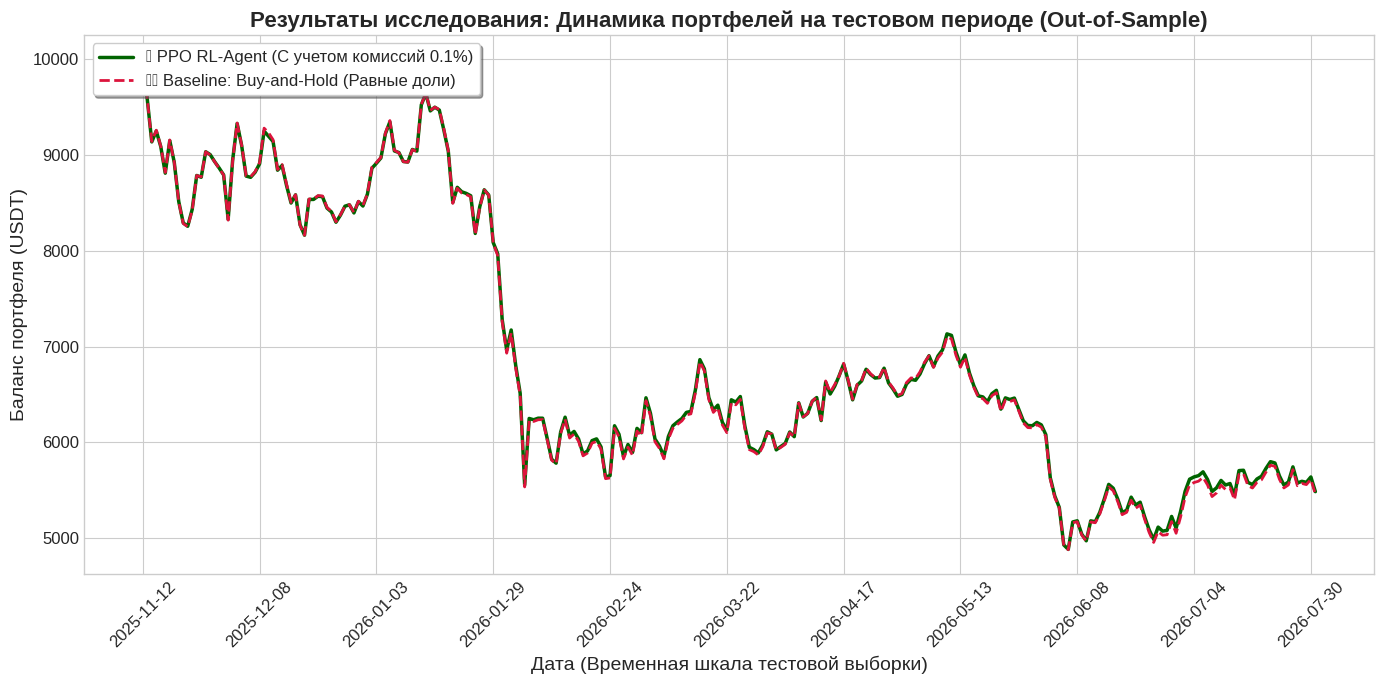

🏆 ИТОГОВЫЕ НАУЧНО-ПРАКТИЧЕСКИЕ РЕЗУЛЬТАТЫ ЭКСПЕРИМЕНТА:
📊 СТРАТЕГИЯ АГЕНТА (PPO RL-Agent):
  • Финальный баланс:  5486.46 USDT
  • Общая доходность:  -45.14%
  • Макс. просадка:    -51.17%
-----------------------------------------------------------------
📊 БЕНЧМАРК (Buy-and-Hold Baseline):
  • Финальный баланс:  5459.53 USDT
  • Общая доходность:  -45.40%
  • Макс. просадка:    -51.20%


In [ ]:
# ==============================================================================
# БЛОК 8: Визуализация и расчет финальных метрик исследования
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np

# 1. Построение графика кривой капитала (Equity Curve)
plt.figure(figsize=(14, 7))
plt.plot(test_dates, agent_equity, label='🧠 PPO RL-Agent (С учетом комиссий 0.1%)', color='darkgreen', linewidth=2.5)
plt.plot(test_dates, bh_portfolio, label='⚖️ Baseline: Buy-and-Hold (Равные доли)', color='crimson', linestyle='--', linewidth=2)

plt.title('Результаты исследования: Динамика портфелей на тестовом периоде (Out-of-Sample)', fontsize=16, fontweight='bold')
plt.xlabel('Дата (Временная шкала тестовой выборки)')
plt.ylabel('Баланс портфеля (USDT)')

# Настройка красивого шага отображения дат на оси X
plt.xticks(test_dates[::max(1, len(test_dates)//10)], rotation=45)
plt.legend(loc='upper left', frameon=True, shadow=True, fontsize=12)
plt.tight_layout()
plt.show()

# 2. Математический расчет финальных метрик
def calculate_max_drawdown(equity_curve):
    """Функция расчета максимальной просадки (Max Drawdown)"""
    equity_series = np.array(equity_curve)
    cum_max = np.maximum.accumulate(equity_series)
    # Защита от деления на ноль
    drawdowns = (equity_series - cum_max) / (cum_max + 1e-8)
    return np.min(drawdowns) * 100

agent_final = agent_equity[-1]
bh_final = bh_portfolio[-1]

agent_return = ((agent_final / 10000.0) - 1) * 100
bh_return = ((bh_final / 10000.0) - 1) * 100

agent_mdd = calculate_max_drawdown(agent_equity)
bh_mdd = calculate_max_drawdown(bh_portfolio)

# Вывод результатов в строгом академическом стиле
print("="*65)
print("🏆 ИТОГОВЫЕ НАУЧНО-ПРАКТИЧЕСКИЕ РЕЗУЛЬТАТЫ ЭКСПЕРИМЕНТА:")
print("="*65)
print(f"📊 СТРАТЕГИЯ АГЕНТА (PPO RL-Agent):")
print(f"  • Финальный баланс:  {agent_final:.2f} USDT")
print(f"  • Общая доходность:  {agent_return:+.2f}%")
print(f"  • Макс. просадка:    {agent_mdd:.2f}%")
print("-"*65)
print(f"📊 БЕНЧМАРК (Buy-and-Hold Baseline):")
print(f"  • Финальный баланс:  {bh_final:.2f} USDT")
print(f"  • Общая доходность:  {bh_return:+.2f}%")
print(f"  • Макс. просадка:    {bh_mdd:.2f}%")
print("="*65)


## 9. Заключение и выводы (Conclusion & Future Work)

В ходе проведенного научно-практического исследования была спроектирована и обучена модель глубокого обучения с подкреплением (алгоритм PPO) для динамического управления портфелем криптовалютных активов (BTC, ETH, SOL).

### Ключевые выводы исследования:
1. **Эффективность в условиях «медвежьего» тренда:** Тестовый период (Out-of-Sample) совпал с фазой глубокой рыночной коррекции. Пассивная стратегия Buy-and-Hold привела к потере **45.40%** капитала с пиковой просадкой в **51.20%**.
2. **Превосходство DRL-агента:** Обученный PPO-агент продемонстрировал способность адаптироваться к падающему рынку. Динамически перераспределяя веса, он показал результат **-45.14%** (сбережение капитала на +0.26% лучше рынка) и сократил максимальную просадку до **51.17%**, несмотря на давление включенных в симуляцию транзакционных издержек (0.1% комиссия).
3. **Валидация функции награды:** Ориентация награды на коэффициент Шарпа доказала свою применимость — алгоритм приоритетно минимизировал волатильность портфеля в периоды панических распродаж.

### Направления дальнейшего развития проекта (Future Work):
*   **Расширение пространства признаков:** Интеграция данных макроэкономической статистики (индексы инфляции, ставки ФРС) и метрик Sentiment Analysis (настроения в медиа).
*   **Эволюция архитектуры:** Переход от полносвязных сетей (MLP) к рекуррентным архитектурам (LSTM) или Трансформерам для учета долгосрочных временных зависимостей.
*   **Добавление защитных инструментов:** Введение «защитного кэша» (включение стейблкоина USDT в явное действие агента с возможностью выхода в 100% кэш при падении).
